In [1]:
# Quadratic Equation Solver

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [2]:
# State 
class QuadState(TypedDict):
    a: int
    b: int
    c: int
    
    equation: str
    discriminant: float
    result: str

In [3]:
# Show Equation
def show_equation(state: QuadState) -> QuadState:
    equation = f'{state["a"]}x2{state["b"]}x{state["c"]}'
    
    return {"equation": equation}

# Calculate Discriminant
def calculate_discriminant(state: QuadState) -> QuadState:
    discriminant = state["b"] ** 2 - (4 * state["a"] * state["c"])
    
    return {"discriminant": discriminant}



# Funaction for Real Roots
def real_roots(state: QuadState) -> QuadState:
    root1 = (-state["b"] + state["discriminant"] ** 0.5) / (2 * state["a"])
    root2 = (-state["b"] - state["discriminant"] ** 0.5) / (2 * state["a"])
    result = f'the roots are {root1} and {root2}'
    
    return {"result": result}


# Funaction for Repeated Roots
def repeated_roots(state: QuadState) -> QuadState:
    root = -state["b"] / (2 * state["a"])
    result = f'Only Repeating root is {root}'
    
    return {"result": result}

# Funaction for No Real Roots
def no_real_roots(state: QuadState) -> QuadState:
    result = 'No Real Roots'
    
    return {"result": result}



# FOR CONDITIONAL WORKFLOW
def check_condition(state: QuadState) -> Literal['Real_Roots', 'Repeated_Roots', 'No_Real_Roots']:
    if state['discriminant'] > 0:
        return "Real_Roots"
    elif state["discriminant"] == 0:
        return 'Repeated_Roots'
    else:
        return 'No_Real_Roots'


In [4]:
# Graph 
graph = StateGraph(QuadState)

# Nodes
graph.add_node("Show_Equation", show_equation)
graph.add_node("Calculate_Discriminant", calculate_discriminant)
graph.add_node("Real_Roots", real_roots)
graph.add_node("Repeated_Roots", repeated_roots)
graph.add_node("No_Real_Roots", no_real_roots)

# Eges
graph.add_edge(START, "Show_Equation")
graph.add_edge("Show_Equation", "Calculate_Discriminant")

graph.add_conditional_edges("Calculate_Discriminant", check_condition)

graph.add_edge("Real_Roots", END)
graph.add_edge("Repeated_Roots", END)
graph.add_edge("No_Real_Roots", END)

# Compile
workflow = graph.compile()

In [5]:
# Execute
initail_state = {'a': 2, 'b': 4, 'c': 2}

final_state = workflow.invoke(initail_state)
final_state

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2x24x2',
 'discriminant': 0,
 'result': 'Only Repeating root is -1.0'}

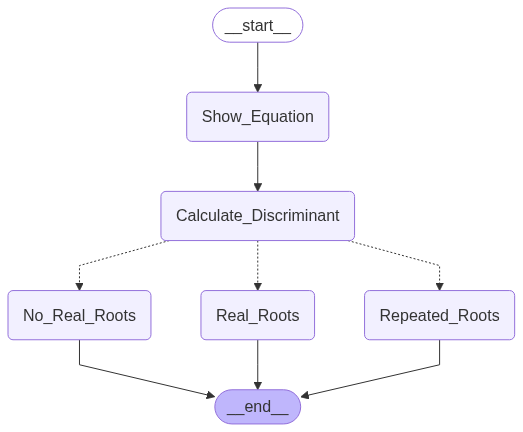

In [6]:
workflow